# 12.12 一個答案同時需要圖與聲音，怎麼檢查兩條線索？


圖片是紅圓，聲音是 440 Hz 單音。提問「形狀與音高是什麼」，希望回 `circle,high`：circle 由圖決定，high 由高於 300 Hz 的聲音規則決定。單看任一路都不足以確定完整答案。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

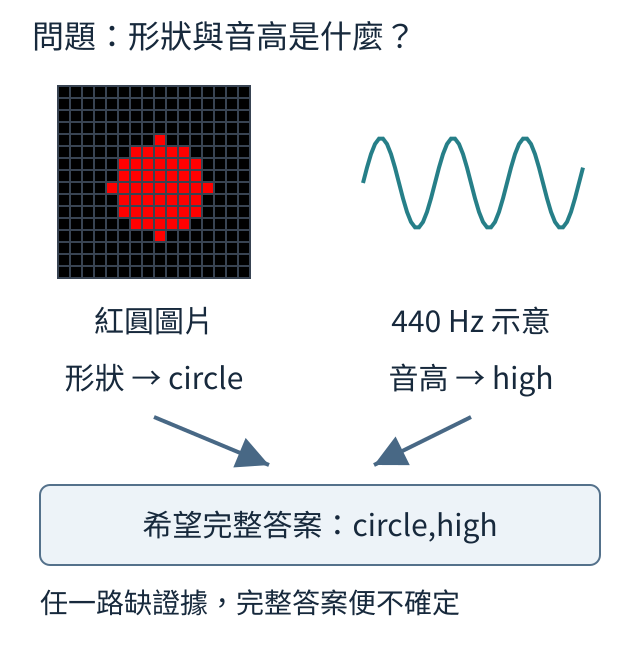

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-12-joint-clues.svg")))

先做一次不更新參數的 `backward`，檢查答案損失是否連到圖、聲音兩個接頭；這一步尚未測試模型是否答對。


In [3]:
import torch
from tiny_perceptron.data import ByteTokenizer
from tiny_perceptron.model import TinyLM, ModelConfig, masked_loss
from tiny_perceptron.multimodal import MultiModalLM, scene, tone

torch.manual_seed(0)
tok = ByteTokenizer()
model = MultiModalLM(TinyLM(ModelConfig(width=8)))
prefix = [tok.bos_id, tok.user_id, tok.image_id, tok.audio_id, tok.eos_id, tok.assistant_id]
answer = tok.encode("circle,high") + [tok.eos_id]
ids = torch.tensor(prefix + answer)
labels = torch.tensor([-100] * len(prefix) + answer)
out = model(ids, labels, image=scene("red", "circle"), waveform=tone(440))
masked_loss(out["logits"], out["labels"]).backward()
print("圖路徑梯度", model.image_projector.weight.grad.norm().item() > 0)
print("音路徑梯度", model.audio_projector.weight.grad.norm().item() > 0)

圖路徑梯度 True
音路徑梯度 True


前綴有 `<image>`、`<audio>` 兩個位置，各以自己的特徵序列替換，再交同一文字核心。圖接頭、音接頭都收到梯度印 True，證明這個答案損失連到兩條路徑；程式沒有更新，不能由此判斷是否已會同時辨識。

材料也要交叉配對：圓低、圓高、方低、方高都出現。如果圓永遠配高音，模型可能只看圖就回出兩段答案。測試時固定圖換聲，只有音高部分應隨新聲改；固定聲換圖，只有形狀部分應隨新圖改。

既有受控合成試驗有 12 題，以下按原題答案評分。拿掉一路後，它負責的部分退回 6/12，而另一路仍對 12/12：

| 輸入條件 | 形狀正確 | 音高正確 | 完整答案正確 |
| --- | ---: | ---: | ---: |
| 圖與聲音都有 | 12/12 | 12/12 | 12/12 |
| 空白圖，聲音保留 | 6/12 | 12/12 | 6/12 |
| 圖保留，聲音靜音 | 12/12 | 6/12 | 6/12 |
| 空白圖加靜音 | 6/12 | 6/12 | 3/12 |

替換一路後按新材料重標，完整答案亦對 12/12；每對都跟著該部分改，支持這個有限控制使用兩路。驗證集只有 8/12，且部分頻率曾用於聲音入口預訓練，所以不能把最後表格宣稱為所有線索都完全未見的測試。

練習指出空白圖/靜音行的分數，為何不是「空白圖應有某形狀」或「靜音應 high」？它們量的是拿掉證據後，模型與原題答案的關係。

<details>
<summary>回顧與查證</summary>

可回顧：[10.7圖片展開](https://birdhackor.github.io/tiny-perceptron-vlm/10.7.html)、[12.9聲音展開](https://birdhackor.github.io/tiny-perceptron-vlm/12.9.html)、[11.8按規則替換](https://birdhackor.github.io/tiny-perceptron-vlm/11.8.html)。

原實驗的資料切分、更新設定與逐題結果見[既有實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/joint.json)；重做入口見[實驗說明](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/README.md)。這是上述有限任務的歷史紀錄。

</details>
